In [ ]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

sys.path.append(os.path.abspath(os.path.join("..")))
from src.preprocessing import load_and_clean_data, prepare_data_for_training, get_preprocessor
from src.plotting import (
    plot_distributions, 
    plot_relationships, 
    plot_advanced_features, 
    plot_correlation_matrix
)

In [ ]:
# %% [markdown]
# ### 1. Identify and Load the Latest Dataset
# We query the `metadata.json` registry to find the most recent scraping session.

# %%
metadata_path = "../data/metadata.json"

if os.path.exists(metadata_path):
    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    
    # Get the latest dataset based on 'scraped_at'
    latest_id = max(metadata.keys(), key=lambda k: metadata[k]['scraped_at'])
    latest_file = f"{latest_id}.csv"
    info = metadata[latest_id]
    
    print(f"Loading latest dataset: {latest_file}")
    print(f"Context: {info['property_type']} in {', '.join(info['cities'])}")
    
    dataset_path = os.path.join("..", "data", latest_file)
else:
    # Fallback if metadata doesn't exist
    dataset_path = "../data/dataset.csv"
    print("Metadata not found, trying default dataset.csv")

# Load and clean using modular logic
df = load_and_clean_data(dataset_path)
df.head()

Loading latest dataset: dataset_1775390681.csv
Context: flat in Beograd, Novi Sad


,ID,City,Municipality,Neighborhood,Area,Rooms,Total_Price_EUR,Scrape_Date,Price_per_Unit_EUR,Rooms_Numeric
0,5425646979954,Beograd,Novi Beograd,Blok 8a,63.00,3.0 Broj soba,210000.0,2026-04-05 14:04:41,3333.333333,3.0
1,5425646984027,Beograd,Savski venac,Centar,150.00,5.0 Broj soba,450000.0,2026-04-05 14:04:41,3000.000000,5.0
2,5425646984033,Beograd,Novi Beograd,Blok 23,84.00,3.0 Broj soba,275000.0,2026-04-05 14:04:41,3273.809524,3.0
3,5425646984035,Beograd,Voždovac,Saobraćajni fakultet,70.21,3.0 Broj soba,269000.0,2026-04-05 14:04:41,3831.363054,3.0
4,5425646782812,Beograd,Savski venac,Beograd na vodi,80.35,3.0 Broj soba,375000.0,2026-04-05 14:04:41,4667.081518,3.0


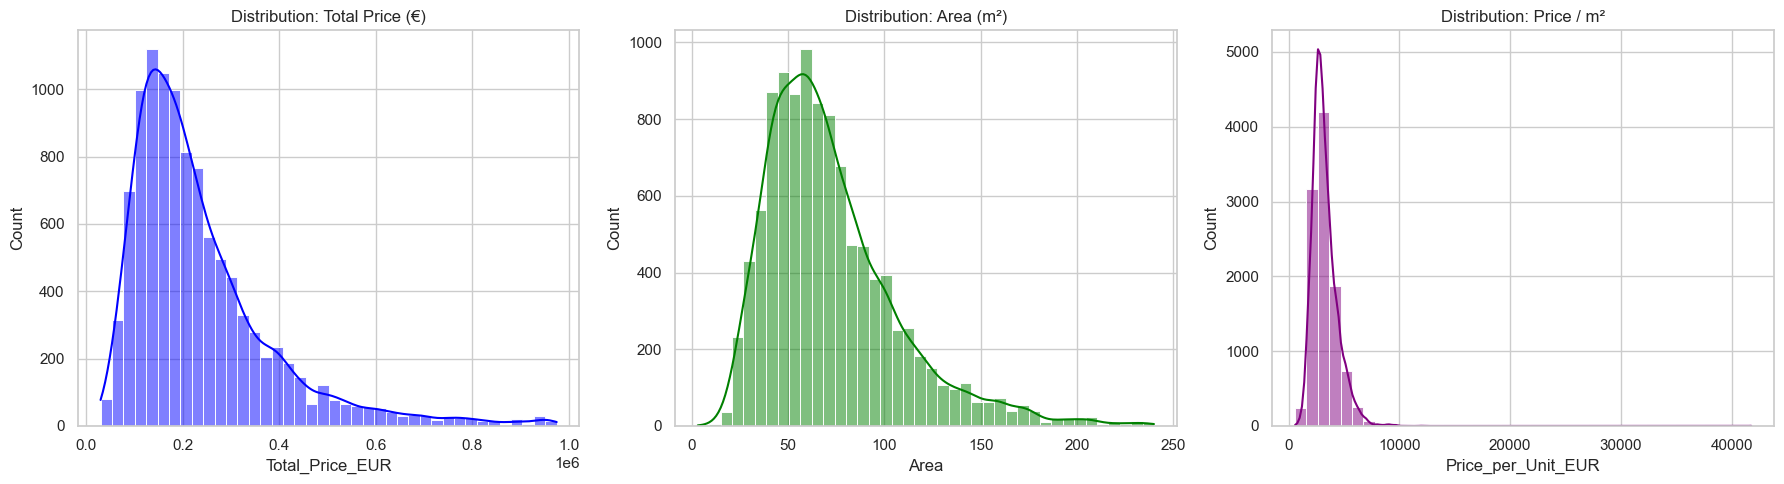

c:\Users\xogi0\Desktop\met-si\SEMESTAR 8\CS490\project\src\plotting.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


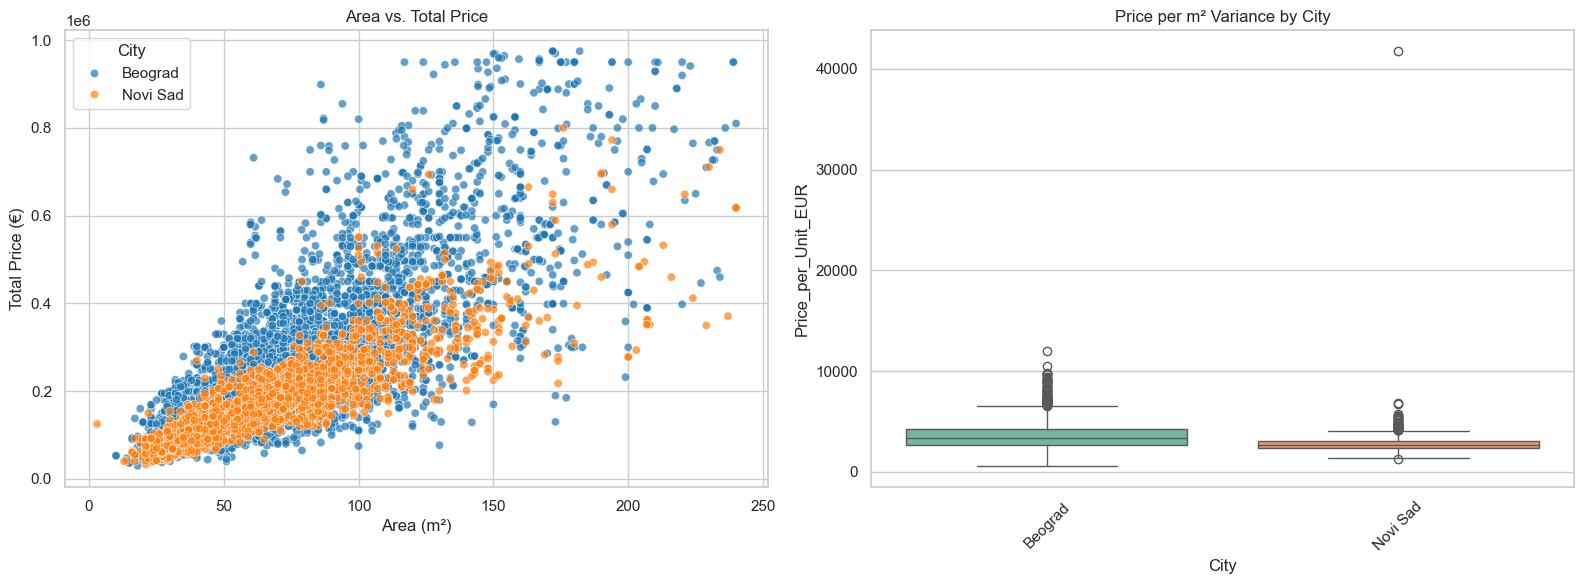

c:\Users\xogi0\Desktop\met-si\SEMESTAR 8\CS490\project\src\plotting.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
c:\Users\xogi0\Desktop\met-si\SEMESTAR 8\CS490\project\src\plotting.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


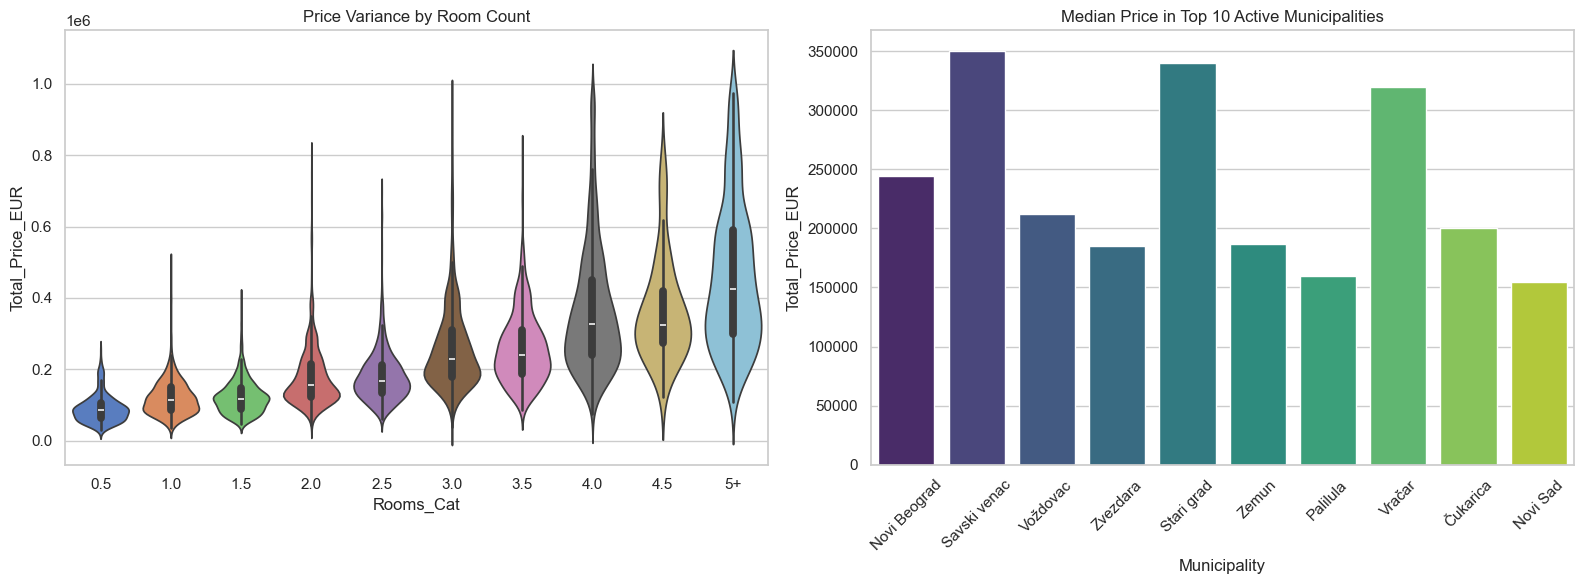

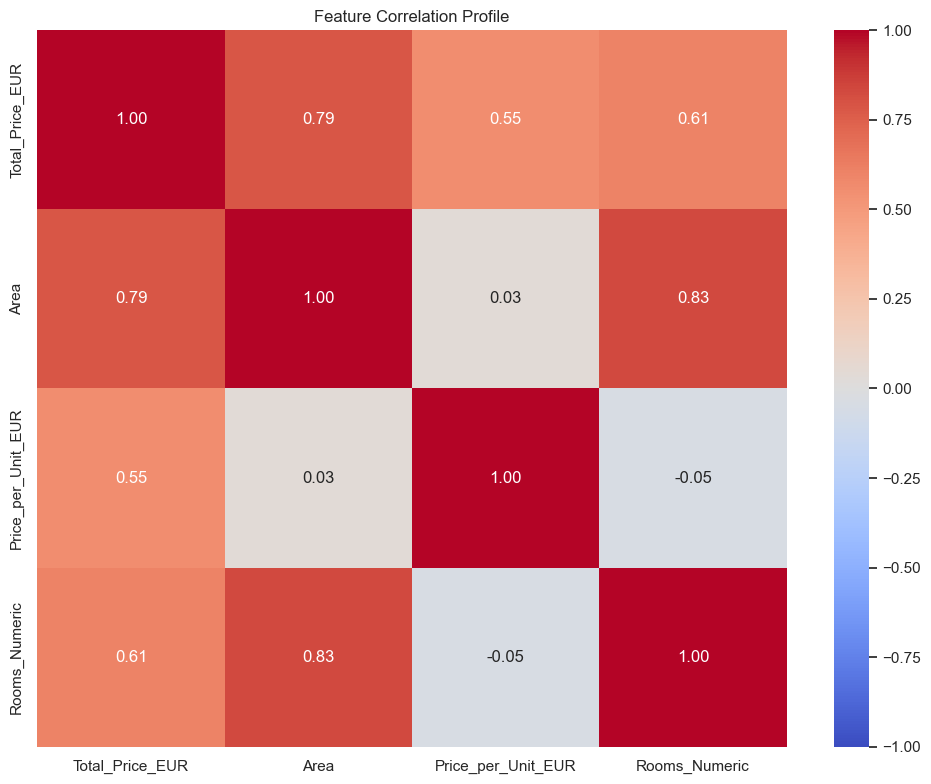

In [ ]:
# %% [markdown]
# ### 2. Exploratory Data Analysis (EDA)
# Visualizing market trends, distributions, and feature synergies.

# %%
# Distributions of Price and Area
plot_distributions(df)
plt.show()

# Relationships between Area, Price, and City
plot_relationships(df)
plt.show()

# Room quantity and Municipality impact
plot_advanced_features(df)
plt.show()

# Correlation Heatmap
plot_correlation_matrix(df)
plt.show()

In [ ]:
# %% [markdown]
# ### 3. Pipeline Simulation (Production-Ready ML)
# Instead of manual dummy variables, we use the `Pipeline` which encapsulates 
# the `StandardScaler`, `OneHotEncoder`, and `Imputer`.

# %%
# 1. Separate features and target
target_col = "Total_Price_EUR"
X, y = prepare_data_for_training(df, target_col=target_col)

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the dynamic preprocessor (detects columns automatically)
preprocessor = get_preprocessor(X_train)

# 4. Build and fit the Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

print("Training the production-ready pipeline...")
model_pipeline.fit(X_train, y_train)

In [ ]:
# %% [markdown]
# ### 4. Evaluation
# Calculating performance metrics on the test set.

# %%
preds = model_pipeline.predict(X_test)

r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)

print(f"--- Model Evaluation ({target_col}) ---")
print(f"R-Squared Error: {r2:.4f}")
print(f"Mean Absolute Error: €{mae:,.2f}")

In [ ]:
# %% [markdown]
# ### 5. Manual Prediction Test
# Simulating a raw input like the Streamlit App would receive.

# %%
# Sample input (Area, Rooms, City, Municipality)
sample_input = pd.DataFrame([{
    'Area': 65.0,
    'Rooms_Numeric': 2.5,
    'City': 'Beograd',
    'Municipality': 'Zvezdara'
}])

# The pipeline handles all encoding/scaling internally
predicted_price = model_pipeline.predict(sample_input)[0]
print(f"Predicted Price for 65m2 flat in Zvezdara: €{predicted_price:,.2f}")